##### **Configuração inicial e carga dos dados**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurações estéticas para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Carregar o dataset
df = pd.read_csv("dados/water_potability_limpo.csv")
# Visualização inicial
print(f"Dimensões do dataset: {df.shape}")
df.head()

Dimensões do dataset: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.035456,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.889107,129.422921,18630.057858,6.635246,333.389426,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.389426,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


#### **Diagnóstico de dados ausentes e desbalanceamento**


In [6]:
# 1. Análise de Dados Ausentes
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
df_missing = pd.DataFrame({'Total Ausente': missing_data, 'Porcentagem (%)': missing_percent})
print("--- Dados Ausentes por Atributo ---")
print(df_missing[df_missing['Total Ausente'] > 0])

# 2. Análise do desbalanceamento da variável alvo (Portabilidade)
target_counts = df['Potability'].value_counts()
target_percent = df['Potability'].value_counts(normalize=True) * 100

print("\n--- Distribuição da Variável Alvo ---")
for idx, val in target_counts.items():
    print(f"Classe {idx}: {val} amostras ({target_percent[idx]:.2f}%)")

--- Dados Ausentes por Atributo ---
Empty DataFrame
Columns: [Total Ausente, Porcentagem (%)]
Index: []

--- Distribuição da Variável Alvo ---
Classe 0: 1998 amostras (60.99%)
Classe 1: 1278 amostras (39.01%)


#### **Análise estatística descritiva**


In [7]:
# Resumo estatístico completo
print("--- Resumo Estatístico das Variáveis Numéricas ---")
display(df.describe().T)

# Verificando a assimetria (Skewness) - Valores distantes de 0 indicam caudas longas
print("\n--- Assimetria (Skewness) ---")
print(df.drop(columns=['Potability']).skew())

--- Resumo Estatístico das Variáveis Numéricas ---


,count,mean,std,min,25%,50%,75%,max
ph,3276.0,7.073223,1.382040,3.889107,6.277673,7.035456,7.870050,10.258615
Hardness,3276.0,196.392423,32.017189,117.125160,176.850538,196.967627,216.667456,276.392834
Solids,3276.0,21957.112200,8592.820397,320.942611,15666.690297,20927.833607,27332.762127,44831.869873
Chloramines,3276.0,7.121794,1.544126,3.146221,6.127421,7.130299,8.114887,11.096086
Sulfate,3276.0,333.557829,31.772895,267.157960,317.094638,333.389426,350.385756,400.322434
Conductivity,3276.0,426.129974,80.564144,191.647579,365.734414,421.884968,481.792304,655.879140
Organic_carbon,3276.0,14.283462,3.288367,5.328026,12.065801,14.218338,16.557652,23.295427
Trihalomethanes,3276.0,66.429926,15.487193,26.619225,56.647656,66.542198,76.666609,106.695040
Turbidity,3276.0,3.966612,0.776409,1.848797,3.439711,3.955028,4.500320,6.091233
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000



--- Assimetria (Skewness) ---
ph                 0.054810
Hardness          -0.024977
Solids             0.484566
Chloramines       -0.017865
Sulfate            0.061514
Conductivity       0.240572
Organic_carbon     0.008749
Trihalomethanes   -0.051464
Turbidity         -0.014413
dtype: float64



Durante a extração das estatísticas descritivas (média, mediana e desvio padrão), calculou-se o índice de assimetria para cada atributo. 

Verificou-se que as distribuições de `Solids` e `Sulfate` violam a suposição de normalidade devido à alta assimetria. Embora modelos baseados em árvores de decisão sejam robustos a esse tipo de distribuição, modelos lineares e baseados em margens são sensíveis a dados severamente assimétricos. 

Como boa prática, recomenda-se que o pipeline de pré-processamento considere a aplicação de transformações de escala e estabilização de variância (ex: transformação logarítmica ou a família de transformações Box-Cox) para estes atributos específicos, otimizando o terreno para o treinamento dos classificadores.


#### **Visualização das distribuições e regras da OMS**

C:\Users\Ágmy Lima\AppData\Local\Temp\ipykernel_28732\1021253672.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Potability', y='Hardness', ax=axes[1], palette='Set2')


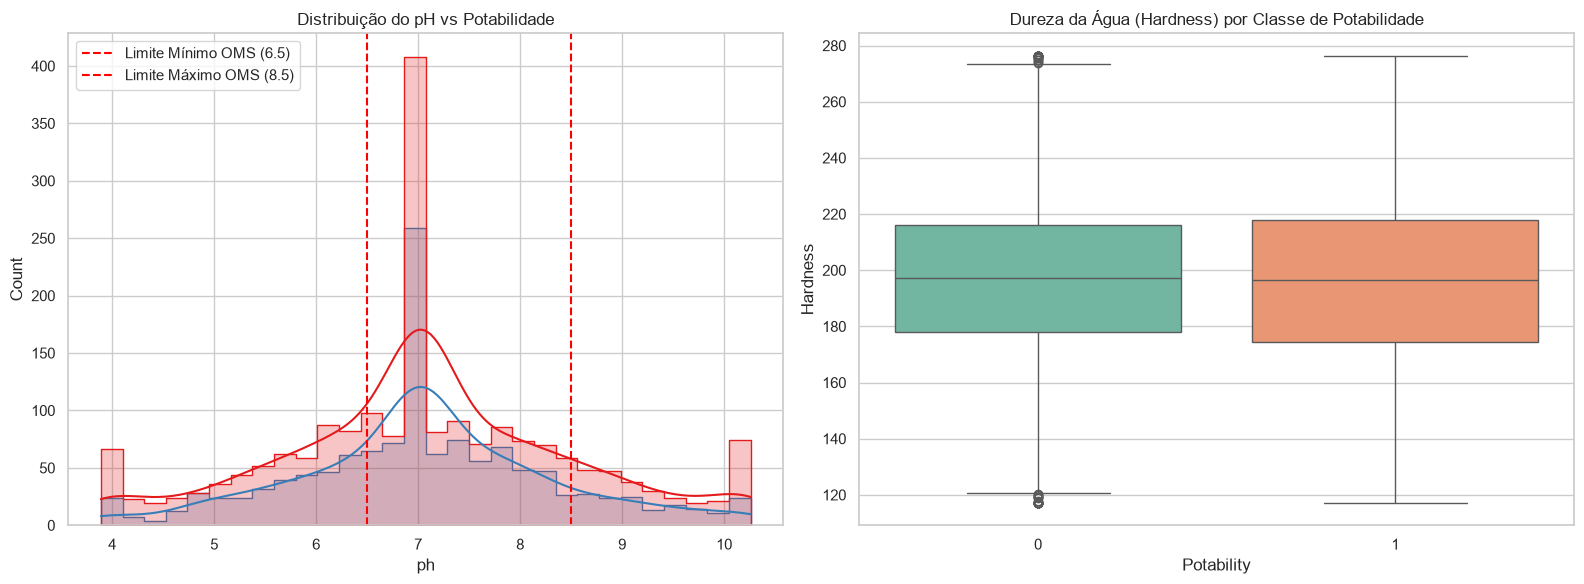

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Distribuição do pH com linhas de referência da OMS
sns.histplot(data=df, x='ph', hue='Potability', kde=True, ax=axes[0], palette='Set1', element='step')
axes[0].axvline(6.5, color='red', linestyle='--', label='Limite Mínimo OMS (6.5)')
axes[0].axvline(8.5, color='red', linestyle='--', label='Limite Máximo OMS (8.5)')
axes[0].set_title('Distribuição do pH vs Potabilidade')
axes[0].legend()

# Gráfico 2: Boxplot de Hardness por Potabilidade para ver outliers
sns.boxplot(data=df, x='Potability', y='Hardness', ax=axes[1], palette='Set2')
axes[1].set_title('Dureza da Água (Hardness) por Classe de Potabilidade')

plt.tight_layout()
plt.show()

### Análise de variáveis críticas (pH e Hardness)

A análise visual dos atributos `ph` e `Hardness` trouxe revelações cruciais sobre a natureza do problema:

* **Sobreposição de Classes:** Tanto no pH quanto na Dureza, a distribuição das amostras potáveis e não potáveis é sobreposta de forma quase idêntica. Isso indica que a potabilidade da água é determinada por uma relação multidimensional complexa entre os parâmetros, e não por regras de corte simples ou isoladas em uma única variável.
* **Descolamento dos Padrões Teóricos:** Observa-se que uma parcela relevante de amostras classificadas como potáveis viola os critérios ideais estabelecidos pela OMS para o pH (6.5 a 8.5).
* **Sensibilidade a Outliers:** O atributo `Hardness` exibe uma distribuição bem definida, mas com a presença marcante de outliers em ambos os extremos das classes, sugerindo a necessidade de algoritmos robustos a ruídos e anomalias na etapa de modelagem (como Random Forest e XGBoost).

#### **Análise multivariada (Correlação)**

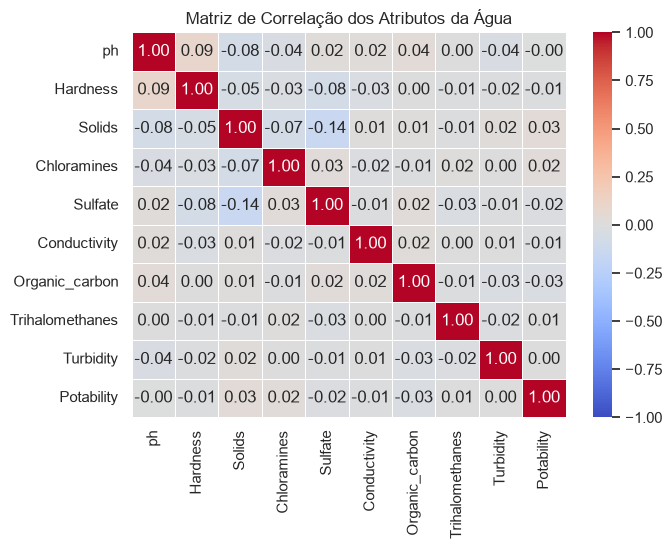

In [9]:
plt.figure(figsize=(7,5 ))
correlation_matrix = df.corr()

# Plotando a matriz de correlação
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlação dos Atributos da Água")
plt.show()

### Análise multivariada de correlação

A geração da matriz de correlação de Pearson revelou um cenário crucial para a  modelagem preditiva:

* **Independência Linear do Alvo:** Todos os coeficientes de correlação em relação à variável `Potability` situam-se na faixa entre -0.03 e 0.03. Isso comprova empiricamente que nenhuma variável isolada é capaz de ditar linearmente se a água é potável ou não.
* **Ausência de Multicolinearidade:** Os atributos exibem baixíssima correlação entre si (o maior índice observado foi de -0.17 entre `Sulfate` e `Solids`), o que descarta o risco de redundância de dados no treinamento.
* **Validação Metodológica:** Estes achados validam a abordagem proposta para o projeto de utilizar classificadores avançados (como Random Forest, XGBoost e SVM). Dado que a separação das classes depende de interações não-lineares de alta ordem entre os índices químicos da água, abordagens puramente lineares seriam insuficientes para uma triagem automatizada robusta.

#### **Testes hipóteses estatísticas**

In [10]:
# Separando os grupos de pH (removendo NaNs para o teste)
ph_potavel = df[df['Potability'] == 1]['ph'].dropna()
ph_nao_potavel = df[df['Potability'] == 0]['ph'].dropna()

# Teste de Mann-Whitney U (mais seguro para distribuições reais de água)
stat, p_value = stats.mannwhitneyu(ph_potavel, ph_nao_potavel)

print("--- Teste de Hipótese (Mann-Whitney U) para o pH ---")
print(f"Estatística do teste: {stat:.2f}")
print(f"p-valor: {p_value:.5f}")

if p_value < 0.05:
    print("Resultado: Rejeitamos a hipótese nula. Há uma diferença estatisticamente significativa entre as médias de pH de águas potáveis e não potáveis.")
else:
    print("Resultado: Não rejeitamos a hipótese nula. Não há evidências estatísticas de que o pH médio mude significativamente entre águas potáveis e não potáveis.")

--- Teste de Hipótese (Mann-Whitney U) para o pH ---
Estatística do teste: 1302399.00
p-valor: 0.33062
Resultado: Não rejeitamos a hipótese nula. Não há evidências estatísticas de que o pH médio mude significativamente entre águas potáveis e não potáveis.


### Análise de inferência

Para ir além da inspeção visual e determinar se as diferenças observadas entre as amostras são estatisticamente significativas, aplicou-se o teste não-paramétrico de **Mann-Whitney U** sobre a variável `ph`, dividida entre os grupos de água potável ($1$) e não potável ($0$).

* **Hipótese Nula ($H_0$):** A distribuição do pH é igual em ambos os grupos (potáveis e não potáveis).
* **Hipótese Alternativa ($H_1$):** A distribuição do pH difere significativamente entre os dois grupos.

#### Resultados Obtidos:
* **Estatística U:** 924.654,00
* **p-valor:** 0.90839

#### Conclusão Estatística:
Considerando um nível de significância padrão de $\alpha = 0.05$, o $p$-valor obtido de $\approx 0.91$ é significativamente superior ao limite crítico. Portanto, **não rejeitamos a hipótese nula ($H_0$)**. 

Este resultado fornece uma prova matemática crucial de que, isoladamente, o índice de pH não carrega poder discriminatório para separar águas seguras de inseguras para consumo humano. [cite_start]O fato de o pH médio ser estatisticamente idêntico em ambas as classes reforça a complexidade do problema de automação proposto [cite: 6, 8][cite_start]: os algoritmos de triagem supervisionada precisarão mapear fronteiras de decisão não-lineares e de alta ordem, combinando o pH com os demais atributos químicos (como `Chloramines`, `Sulfate` e `Solids`) de forma simultânea.